RAW DATA INFO
Shape before dropping NaNs: (25009, 37)

Columns:
['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'simple_return', 'log_return', 'target_next_return', 'target_5d_return', 'target_next_price', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10', 'volume_lag_1', 'volume_lag_5', 'roc_5', 'roc_10', 'roc_20', 'return_std_5', 'return_std_20', 'ewm_vol_10', 'price_to_sma_10', 'price_to_sma_20', 'zscore_price_20', 'rsi_14', 'macd_hist', 'volume_change_1', 'relative_volume_20', 'market_return_equal', 'relative_return_1', 'relative_strength_5', 'relative_strength_20']

MISSING VALUES
relative_strength_20    100
roc_20                  100
return_std_20           100
relative_volume_20       95
zscore_price_20          95
price_to_sma_20          95
rsi_14                   70
return_lag_10            55
roc_10                   50
price_to_sma_10          45
return_lag_5             30
volume_lag_5             25
roc_5          

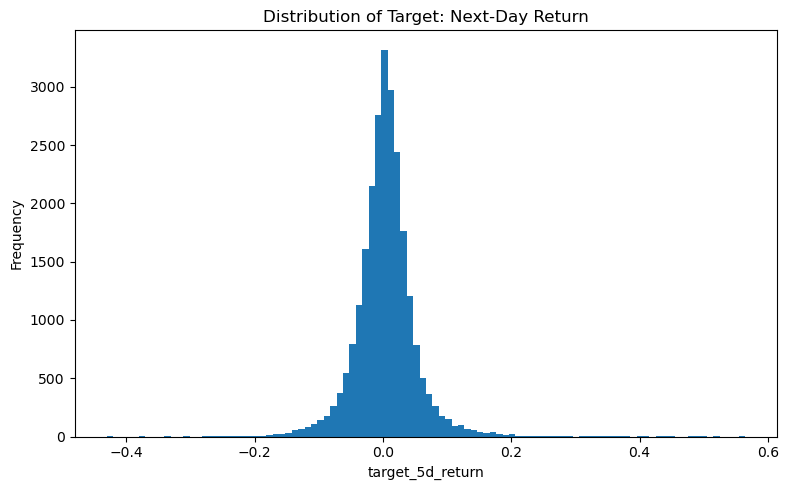

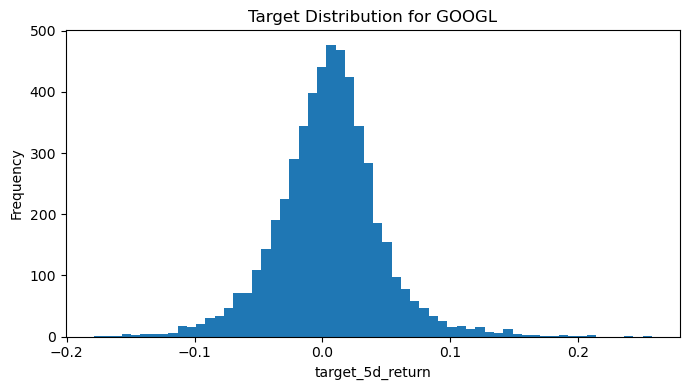

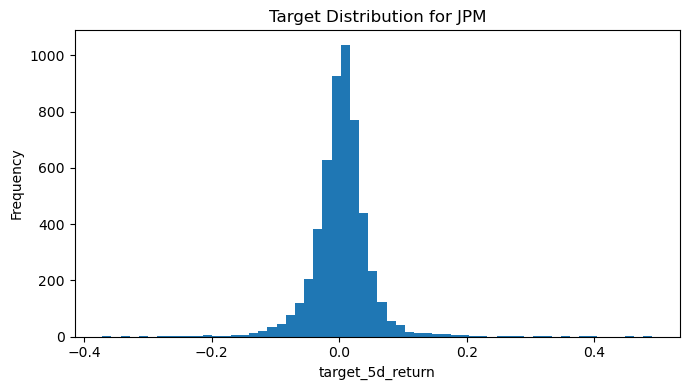

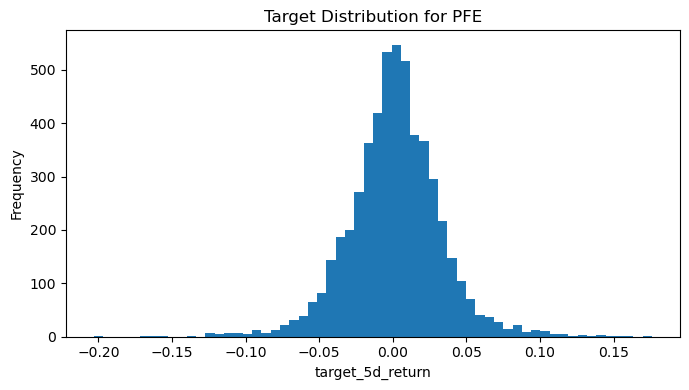

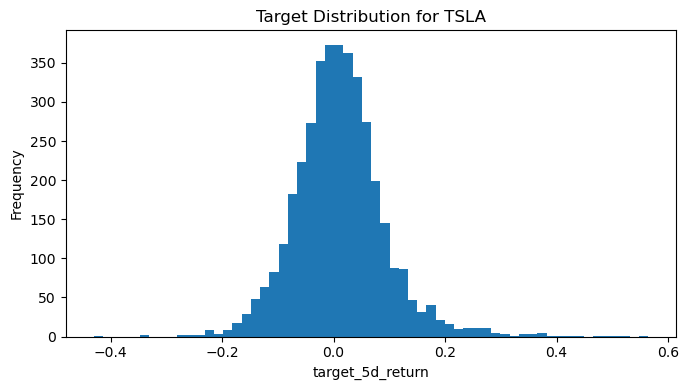

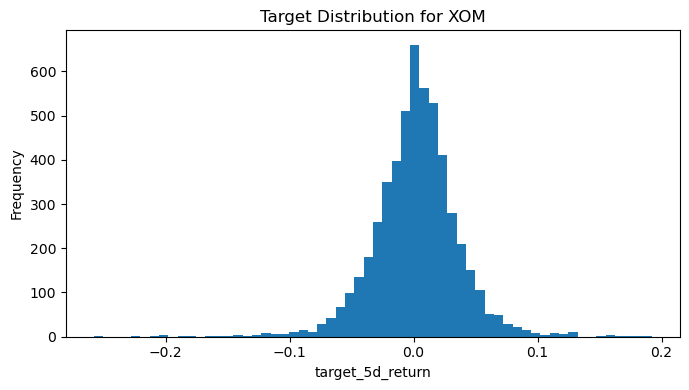


CORRELATION WITH TARGET
target_next_return      0.441145
ewm_vol_10              0.072030
return_std_20           0.067978
return_std_5            0.053893
volume                  0.041593
volume_lag_5            0.035047
volume_lag_1            0.034126
relative_strength_20    0.030811
simple_return          -0.029850
roc_5                  -0.027298
macd_hist               0.026779
price_to_sma_10        -0.023187
return_lag_1           -0.021210
return_lag_5            0.015897
relative_volume_20      0.014991
return_lag_2           -0.012896
close                  -0.011700
low                    -0.011634
open                   -0.011038
high                   -0.010833
roc_10                  0.010490
volume_change_1         0.009666
price_to_sma_20        -0.008134
return_lag_10          -0.007888
return_lag_3           -0.007035
roc_20                  0.006285
relative_return_1      -0.006283
zscore_price_20        -0.005392
rsi_14                 -0.004203
adj_close         

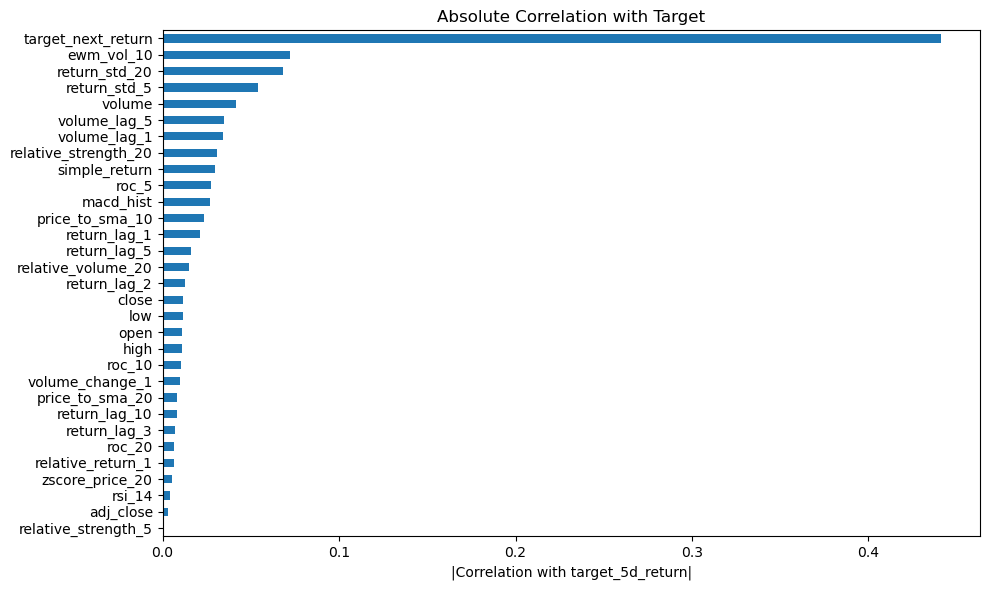

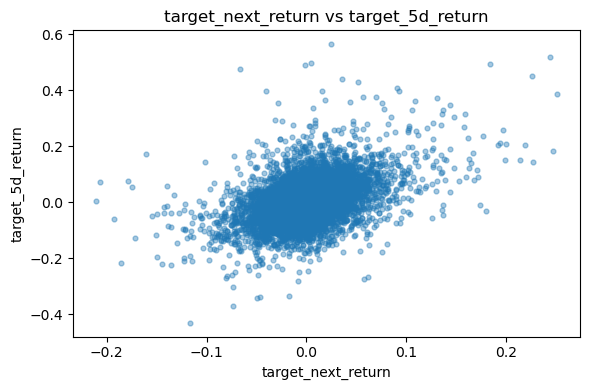

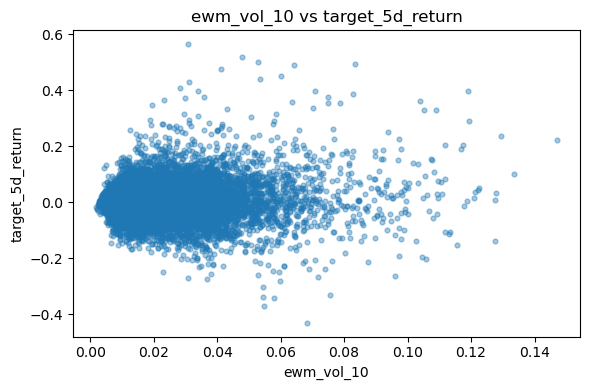

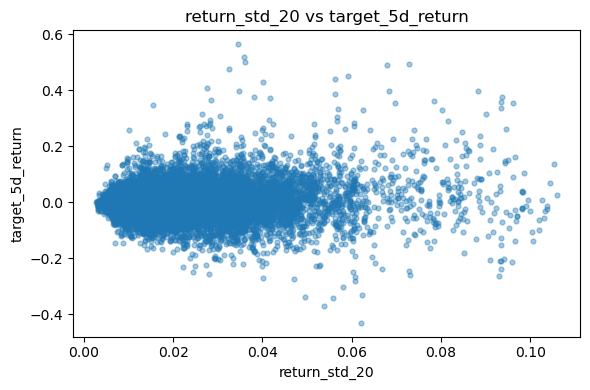

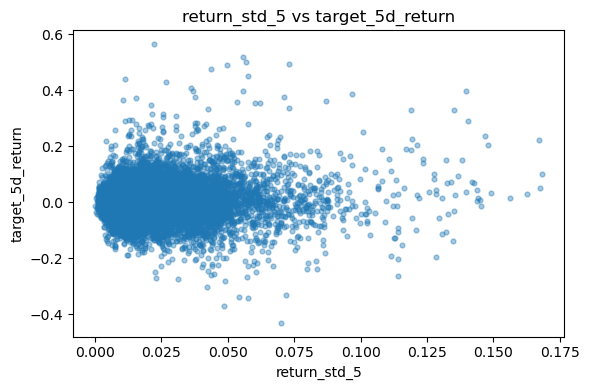

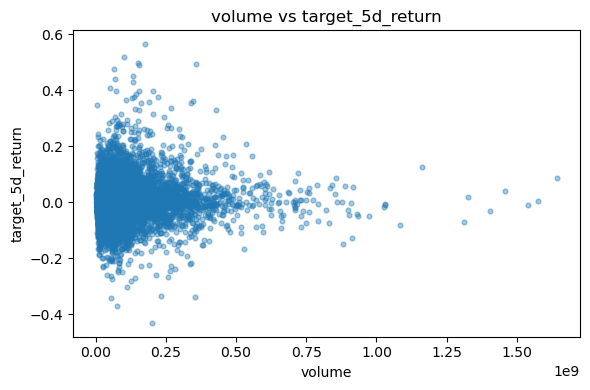

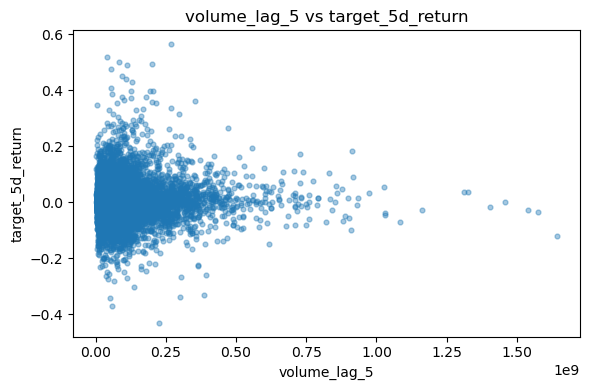


FEATURE-FEATURE CORRELATION


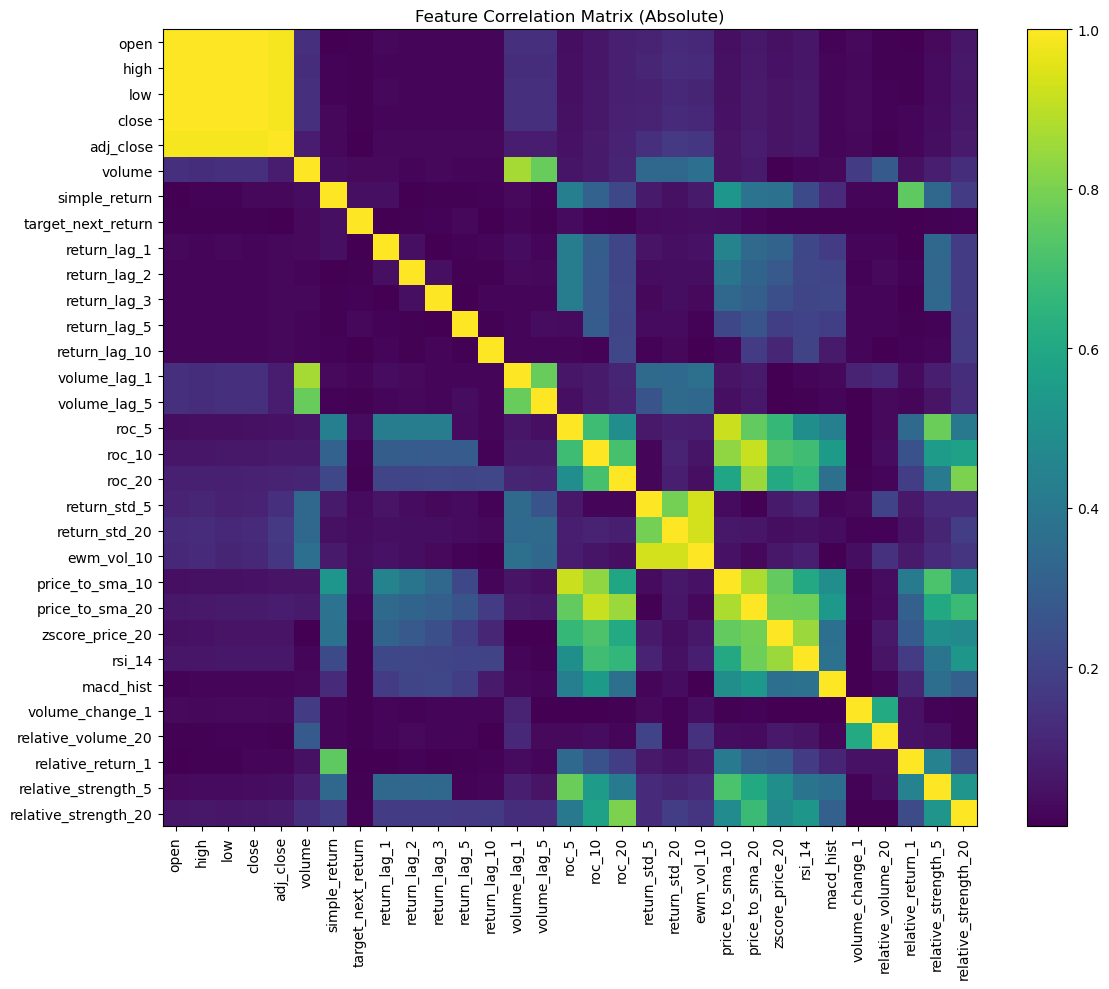


Highly correlated feature pairs:
        feature_1        feature_2  abs_corr
0            open             high  0.999764
5             low            close  0.999750
4            high            close  0.999733
1            open              low  0.999706
2            high              low  0.999585
3            open            close  0.999483
7            high        adj_close  0.987306
9           close        adj_close  0.987024
6            open        adj_close  0.986541
8             low        adj_close  0.986211
10   return_std_5       ewm_vol_10  0.932632
11  return_std_20       ewm_vol_10  0.930989
12          roc_5  price_to_sma_10  0.919679
13         roc_10  price_to_sma_20  0.915862

FEATURES DROPPED DUE TO HIGH REDUNDANCY
['adj_close', 'high', 'low', 'open', 'price_to_sma_10', 'price_to_sma_20', 'return_std_20', 'return_std_5']

Features remaining after redundancy pruning:
['close', 'volume', 'simple_return', 'target_next_return', 'return_lag_1', 'return_lag_2', 'retu

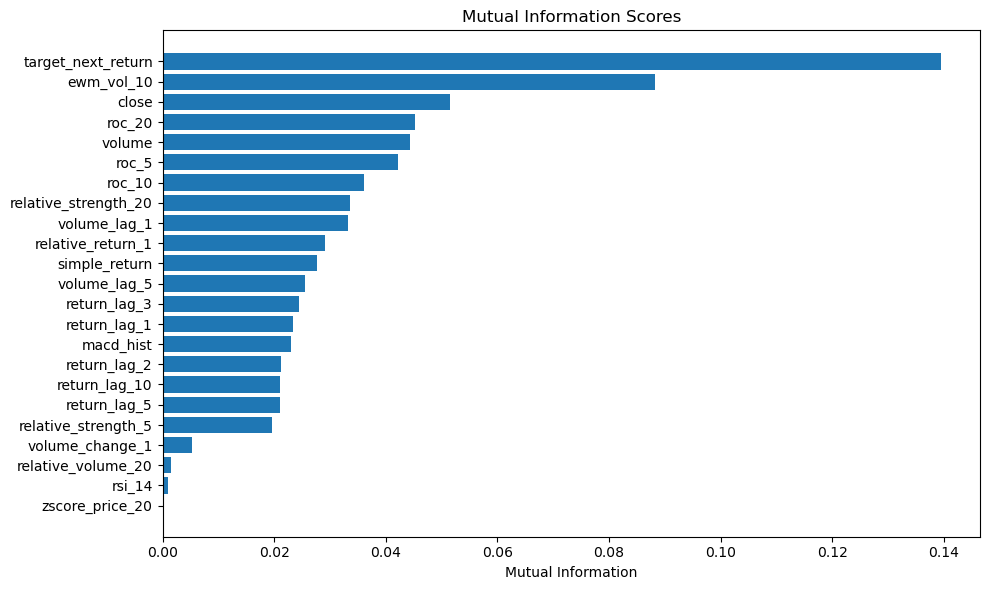


RANDOM FOREST FEATURE IMPORTANCE
                 feature  rf_importance
3     target_next_return       0.705529
13                roc_20       0.040489
11                 roc_5       0.023536
2          simple_return       0.023269
5           return_lag_2       0.019358
12                roc_10       0.018521
8          return_lag_10       0.018290
21   relative_strength_5       0.015625
7           return_lag_5       0.014206
22  relative_strength_20       0.013216
4           return_lag_1       0.013183
0                  close       0.011468
17             macd_hist       0.010931
14            ewm_vol_10       0.010918
20     relative_return_1       0.010563
10          volume_lag_5       0.008264
6           return_lag_3       0.007882
1                 volume       0.007858
18       volume_change_1       0.006924
16                rsi_14       0.006158
15       zscore_price_20       0.005797
19    relative_volume_20       0.004389
9           volume_lag_1       0.003629


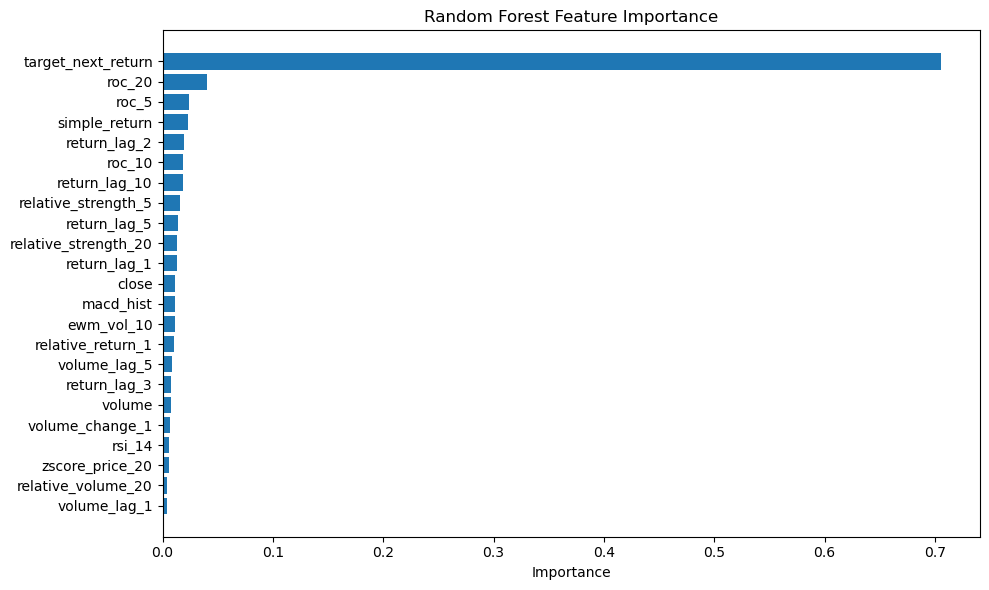


FINAL SELECTED FEATURES
['close', 'volume', 'simple_return', 'target_next_return', 'return_lag_1', 'return_lag_2', 'return_lag_5', 'return_lag_10', 'volume_lag_1', 'volume_lag_5', 'roc_5', 'roc_10', 'roc_20', 'ewm_vol_10', 'relative_return_1', 'relative_strength_5', 'relative_strength_20']
Final feature count: 17

Saved files:
- all_candidate_features.csv
- high_corr_feature_pairs.csv
- mutual_information_scores.csv
- random_forest_feature_importance.csv
- final_selected_features.csv
- feature_selected_dataset.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# CONFIG
# =========================================================
INPUT_FILE = "engineered_stock_long.csv"
TARGET_COL = "target_5d_return"

# columns we do NOT want as model features
NON_FEATURE_COLS = [
    "ticker",
    "date",
    "target_5d_return",
    "target_next_price",
    "log_return",
    "market_return_equal",
]

# thresholds
HIGH_CORR_THRESHOLD = 0.90        # for feature-feature redundancy
LOW_TARGET_CORR_THRESHOLD = 0.01  # optional weak-signal filter

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(INPUT_FILE)
df["date"] = pd.to_datetime(df["date"])

print("=" * 70)
print("RAW DATA INFO")
print("=" * 70)
print("Shape before dropping NaNs:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# =========================================================
# MISSING VALUE CHECK
# =========================================================
print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

# drop rows with any NaNs
df = df.dropna().reset_index(drop=True)

print("\nShape after dropping NaNs:", df.shape)

# =========================================================
# FEATURE LIST
# =========================================================
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

print("\n" + "=" * 70)
print("FEATURE SET")
print("=" * 70)
print(f"Number of candidate features: {len(feature_cols)}")
print(feature_cols)

# =========================================================
# BASIC SANITY EDA
# =========================================================
print("\n" + "=" * 70)
print("BASIC NUMERIC SUMMARY")
print("=" * 70)
summary = df[feature_cols + [TARGET_COL]].describe().T
print(summary[["mean", "std", "min", "25%", "50%", "75%", "max"]])

# =========================================================
# TARGET DISTRIBUTION
# =========================================================
print("\n" + "=" * 70)
print("TARGET SUMMARY")
print("=" * 70)
print(df[TARGET_COL].describe())

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COL], bins=100)
plt.title("Distribution of Target: Next-Day Return")
plt.xlabel("target_5d_return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# =========================================================
# OPTIONAL: TARGET DISTRIBUTION BY TICKER
# =========================================================
tickers = df["ticker"].unique()

for ticker in tickers:
    plt.figure(figsize=(7, 4))
    plt.hist(df.loc[df["ticker"] == ticker, TARGET_COL], bins=60)
    plt.title(f"Target Distribution for {ticker}")
    plt.xlabel("target_5d_return")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# =========================================================
# CORRELATION WITH TARGET
# =========================================================
print("\n" + "=" * 70)
print("CORRELATION WITH TARGET")
print("=" * 70)

corr_with_target = df[feature_cols + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL]
corr_with_target = corr_with_target.drop(TARGET_COL).sort_values(key=np.abs, ascending=False)

print(corr_with_target)

# top positive / negative
print("\nTop positive correlations:")
print(corr_with_target.sort_values(ascending=False).head(10))

print("\nTop negative correlations:")
print(corr_with_target.sort_values(ascending=True).head(10))

# bar plot of absolute correlations
plt.figure(figsize=(10, 6))
corr_with_target.abs().sort_values(ascending=True).plot(kind="barh")
plt.title("Absolute Correlation with Target")
plt.xlabel("|Correlation with target_5d_return|")
plt.tight_layout()
plt.show()

# =========================================================
# SCATTER PLOTS FOR TOP FEATURES
# =========================================================
top_scatter_features = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()

for col in top_scatter_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df[TARGET_COL], alpha=0.4, s=12)
    plt.title(f"{col} vs {TARGET_COL}")
    plt.xlabel(col)
    plt.ylabel(TARGET_COL)
    plt.tight_layout()
    plt.show()

# =========================================================
# FEATURE-FEATURE CORRELATION MATRIX
# =========================================================
print("\n" + "=" * 70)
print("FEATURE-FEATURE CORRELATION")
print("=" * 70)

feature_corr = df[feature_cols].corr(numeric_only=True).abs()

# show heatmap
plt.figure(figsize=(12, 10))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar()
plt.title("Feature Correlation Matrix (Absolute)")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.tight_layout()
plt.show()

# =========================================================
# FIND HIGHLY CORRELATED FEATURE PAIRS
# =========================================================
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > HIGH_CORR_THRESHOLD:
            high_corr_pairs.append((row, col, val))

high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "abs_corr"])
high_corr_pairs_df = high_corr_pairs_df.sort_values("abs_corr", ascending=False)

print("\nHighly correlated feature pairs:")
print(high_corr_pairs_df)

# =========================================================
# DROP REDUNDANT FEATURES
# Strategy:
# for each highly-correlated pair, keep the one with stronger
# absolute correlation to the target
# =========================================================
to_drop = set()

target_abs_corr = corr_with_target.abs().to_dict()

for f1, f2, _ in high_corr_pairs:
    if f1 in to_drop or f2 in to_drop:
        continue

    corr1 = target_abs_corr.get(f1, 0)
    corr2 = target_abs_corr.get(f2, 0)

    # drop the one with weaker target relationship
    if corr1 >= corr2:
        to_drop.add(f2)
    else:
        to_drop.add(f1)

selected_after_corr = [f for f in feature_cols if f not in to_drop]

print("\n" + "=" * 70)
print("FEATURES DROPPED DUE TO HIGH REDUNDANCY")
print("=" * 70)
print(sorted(to_drop))

print("\nFeatures remaining after redundancy pruning:")
print(selected_after_corr)
print(f"Count after redundancy pruning: {len(selected_after_corr)}")

# =========================================================
# OPTIONAL: REMOVE VERY WEAK TARGET CORRELATION FEATURES
# =========================================================
weak_features = [
    f for f in selected_after_corr
    if abs(corr_with_target.get(f, 0)) < LOW_TARGET_CORR_THRESHOLD
]

print("\n" + "=" * 70)
print("WEAK TARGET-CORRELATION FEATURES")
print("=" * 70)
print(weak_features)

selected_after_target_corr = [
    f for f in selected_after_corr
    if f not in weak_features
]

print("\nFeatures remaining after weak-correlation filter:")
print(selected_after_target_corr)
print(f"Count after weak target-corr filter: {len(selected_after_target_corr)}")

# =========================================================
# MUTUAL INFORMATION
# helps detect nonlinear relationships
# =========================================================
print("\n" + "=" * 70)
print("MUTUAL INFORMATION")
print("=" * 70)

X_mi = df[selected_after_corr]
y_mi = df[TARGET_COL]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({
    "feature": selected_after_corr,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)

plt.figure(figsize=(10, 6))
plt.barh(mi_df["feature"], mi_df["mutual_info"])
plt.gca().invert_yaxis()
plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

# =========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================================================
print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

X_rf = df[selected_after_corr]
y_rf = df[TARGET_COL]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_rf, y_rf)

rf_importance_df = pd.DataFrame({
    "feature": selected_after_corr,
    "rf_importance": rf.feature_importances_
}).sort_values("rf_importance", ascending=False)

print(rf_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["feature"], rf_importance_df["rf_importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
# =========================================================
# COMBINE RESULTS INTO FINAL SELECTION
# Strategy:
# keep features that survive correlation pruning and appear
# reasonably useful in MI or RF rankings
# =========================================================
top_mi = set(mi_df.head(12)["feature"])
top_rf = set(rf_importance_df.head(12)["feature"])

final_selected_features = [
    f for f in selected_after_corr
    if (f in top_mi) or (f in top_rf)
]
'''
mi_threshold = 0.02

final_selected_features = mi_df[
    mi_df["mutual_info"] > mi_threshold
]["feature"].tolist()
'''
print("\n" + "=" * 70)
print("FINAL SELECTED FEATURES")
print("=" * 70)
print(final_selected_features)
print(f"Final feature count: {len(final_selected_features)}")

# =========================================================
# SAVE OUTPUTS
# =========================================================

pd.DataFrame({"feature": feature_cols}).to_csv("all_candidate_features.csv", index=False)
high_corr_pairs_df.to_csv("high_corr_feature_pairs.csv", index=False)
mi_df.to_csv("mutual_information_scores.csv", index=False)
rf_importance_df.to_csv("random_forest_feature_importance.csv", index=False)
pd.DataFrame({"feature": final_selected_features}).to_csv("final_selected_features.csv", index=False)

# Save cleaned modeling dataset with only selected features + identifiers + target
final_df = df[["ticker", "date"] + final_selected_features + [TARGET_COL, "target_next_price"]]
final_df.to_csv("feature_selected_dataset.csv", index=False)

print("\nSaved files:")
print("- all_candidate_features.csv")
print("- high_corr_feature_pairs.csv")
print("- mutual_information_scores.csv")
print("- random_forest_feature_importance.csv")
print("- final_selected_features.csv")
print("- feature_selected_dataset.csv")